In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [ ]:
sum(len(files) for _, _, files in os.walk("animals10/raw-img"))
# Number of images

26179

        Class  Image_Count
0        cane         4863
5       ragno         4821
2     gallina         3098
1     cavallo         2623
7    farfalla         2112
8       mucca         1866
6  scoiattolo         1862
4      pecora         1820
3       gatto         1668
9    elefante         1446


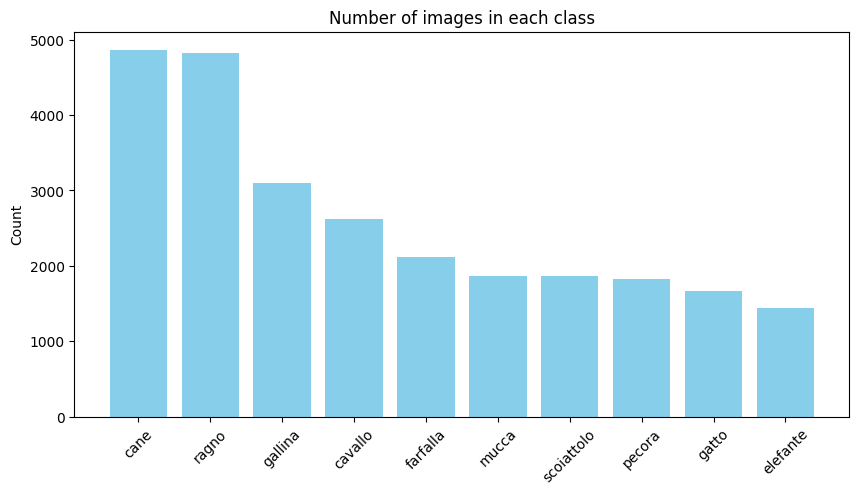

In [ ]:
class_counts = {cls: len(os.listdir(os.path.join(data_dir, cls)))
                for cls in os.listdir(data_dir)
                if os.path.isdir(os.path.join(data_dir, cls))}

df_counts = pd.DataFrame(list(class_counts.items()), columns=["Class", "Image_Count"])
df_counts = df_counts.sort_values(by="Image_Count", ascending=False)

print(df_counts)

plt.figure(figsize=(10, 5))
plt.bar(df_counts["Class"], df_counts["Image_Count"], color="skyblue")
plt.xticks(rotation=45)
plt.title("Number of images in each class")
plt.ylabel("Count")
plt.show()

In [ ]:
records = []

for cls in tqdm(os.listdir(data_dir)):
    cls_path = os.path.join(data_dir, cls)
    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                fmt = img.format
        except:
            width, height, fmt = None, None, "corrupted"

        records.append({
            "class": cls,
            "filename": img_name,
            "path": img_path,
            "width": width,
            "height": height,
            "format": fmt
        })

df_eda = pd.DataFrame(records)

100%|██████████| 10/10 [11:15<00:00, 67.58s/it]


In [ ]:
df_eda.describe()

,width,height
count,26179.000000,26179.000000
mean,320.038810,252.630162
std,196.935326,148.403298
min,60.000000,57.000000
25%,300.000000,200.000000
50%,300.000000,225.000000
75%,300.000000,300.000000
max,6720.000000,6000.000000


In [ ]:
print(df_eda["format"].value_counts())

format
JPEG    26128
PNG        51
Name: count, dtype: int64


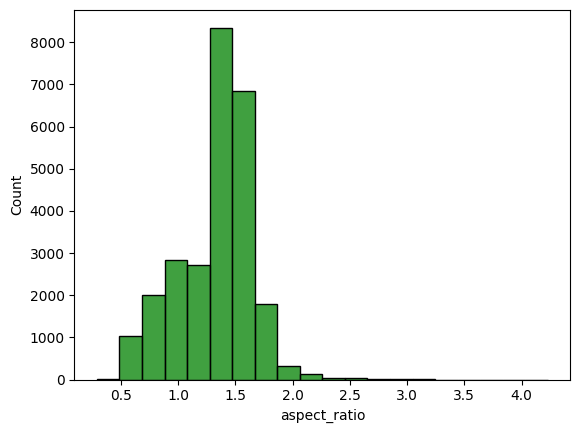

In [ ]:
img_data = []
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(class_path, img_file)
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    aspect = round(w / h, 2)
                    img_data.append({
                        "class": class_name,
                        "width": w,
                        "height": h,
                        "aspect_ratio": aspect
                    })
            except:
                pass

df_images = pd.DataFrame(img_data)

# Aspect ratio distribution
sns.histplot(df_images["aspect_ratio"], bins=20, color='green')
plt.show()

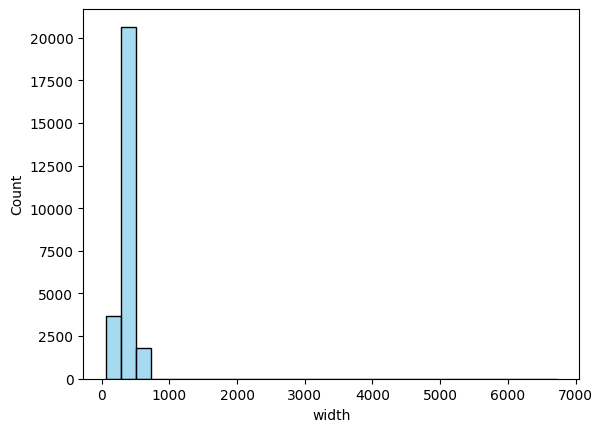

In [ ]:
# Width distribution
sns.histplot(df_images["width"], bins=30, color='skyblue')
plt.show()

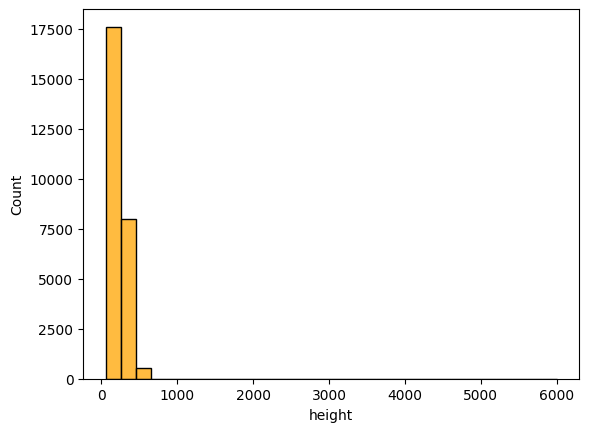

In [ ]:
# Height distribution
sns.histplot(df_images["height"], bins=30, color='orange')
plt.show()

Edge Cases for Images
- Very small or very large images
- Blurry or low-quality images
- Images with multiple animals
- Background clutter or occlusion
- Images in grayscale